# Optical Components

The NSQ engine provides three built-in **compound components** — high-level objects
that assemble multiple physical surfaces automatically:

| Class | Surfaces created | Typical use |
|---|---|---|
| `Lens` | Front face, back face, edge, optional rim | Single refractive element |
| `Doublet` | Front, cemented interface, back, edge | Cemented achromatic doublet |
| `Mirror` | One reflective conic surface | Parabolic/spherical mirror |

Each compound component is created with a **config dataclass** that contains all
geometric and material parameters. This notebook shows how to configure each type,
use the Optiland glass catalog, and apply per-surface overrides.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    CollimatedSourceConfig,
    IrradianceDetectorConfig,
    LensConfig, DoubletConfig, MirrorConfig,
    SurfaceConfig, InteractionType,
    NSQMaterial, VACUUM,
    LambertianBSDF,
)

spec = Spectrum.monochromatic(0.55)  # 550 nm

## 1. Materials

`LensConfig.material` accepts either a glass catalog name string or an
`NSQMaterial` instance.

**Using the glass catalog:**

In [2]:
# Look up glass by catalog name - same names as the sequential engine
nbk7 = NSQMaterial.from_glass('N-BK7')
nsf11 = NSQMaterial.from_glass('N-SF11')

wl = np.array([0.45, 0.55, 0.65])
print("N-BK7  refractive index at 450/550/650 nm:", nbk7.n(wl).round(5))
print("N-SF11 refractive index at 450/550/650 nm:", nsf11.n(wl).round(5))

# VACUUM is a built-in constant: n = 1.0 everywhere
print("VACUUM refractive index at 550 nm       :", VACUUM.n(0.55))

N-BK7  refractive index at 450/550/650 nm: [1.52532 1.51852 1.51452]
N-SF11 refractive index at 450/550/650 nm: [1.81916 1.79115 1.77663]
VACUUM refractive index at 550 nm       : 1.0


## 2. Lens

`LensConfig` defines a singlet. Required fields:
- `r1`, `r2` — radii of curvature [mm] (positive = centre on +z side)
- `thickness` — centre thickness [mm]
- `material` — glass name or `NSQMaterial`
- `front_aperture_radius` — semi-diameter [mm]

Optional: `conic1`, `conic2` for aspheric surfaces (0 = sphere).

The lens automatically creates an absorbing cylindrical edge and, when front and
back apertures differ, an annular rim plane.

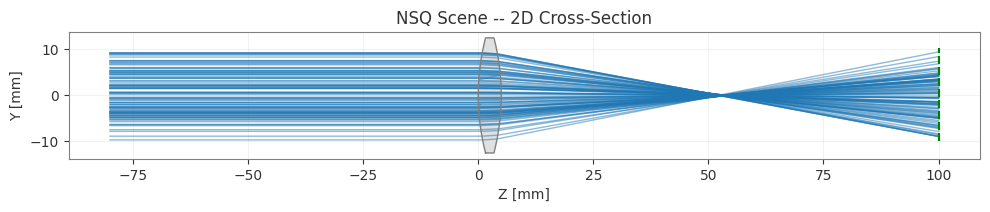

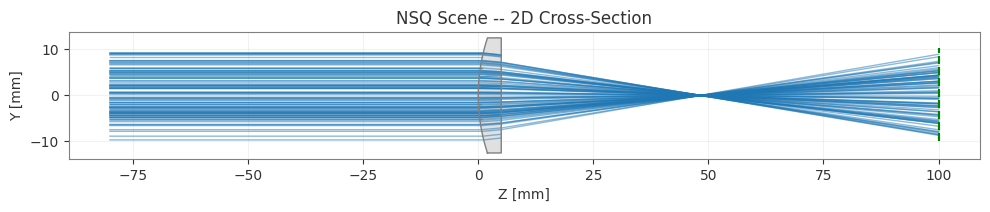

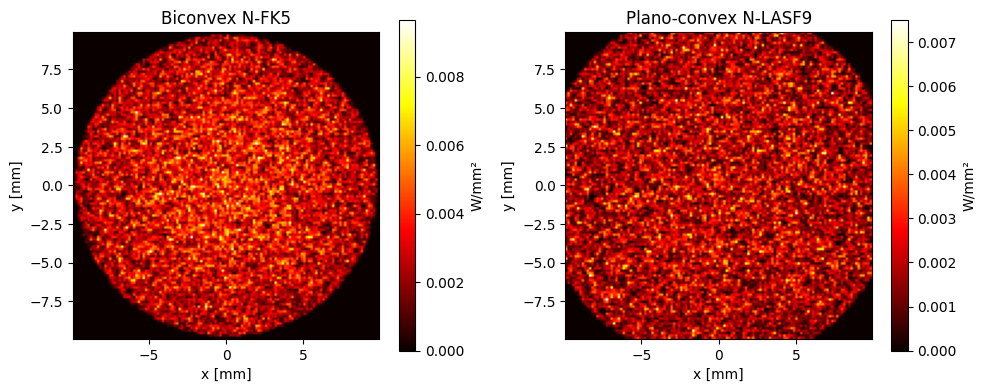

In [3]:
def trace_through_lens(lens_config, source_z=-80, detector_z=100, n_rays=30_000):
    scene = NSQScene()
    scene.add_source(
        'S', CoordinateSystem(z=source_z),
        CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0),
    )
    scene.add_lens('L', CoordinateSystem(z=0), lens_config)
    scene.add_detector(
        'D', CoordinateSystem(z=detector_z),
        IrradianceDetectorConfig(width=20, height=20, num_pixels_x=128, num_pixels_y=128),
    )
    result = scene.trace(num_rays=n_rays, seed=42)
    scene.view()
    return result.detectors['D']

# Biconvex N-FK5 lens
biconvex = LensConfig(r1=50, r2=-50, thickness=5, material='N-FK5',
                      front_aperture_radius=12.5)

# Plano-convex N-LASF9 lens
planoconvex = LensConfig(r1=40, r2=np.inf, thickness=5, material='N-LASF9',
                         front_aperture_radius=12.5)

irr_biconvex   = trace_through_lens(biconvex)
irr_planoconvex = trace_through_lens(planoconvex)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, irr, title in zip(axes, [irr_biconvex, irr_planoconvex],
                          ['Biconvex N-FK5', 'Plano-convex N-LASF9']):
    im = ax.imshow(irr.irradiance, origin='lower', cmap='hot', aspect='equal',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                            irr.y_coords[0], irr.y_coords[-1]])
    plt.colorbar(im, ax=ax, label='W/mm²')
    ax.set_title(title)
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.tight_layout()
plt.show()

## 3. Doublet (Cemented Achromat)

A `Doublet` consists of a crown element (material1) and a flint element (material2)
cemented together. It has three radii of curvature and two thicknesses.

Using a broadband spectrum reveals the chromatic correction:

Doublet surfaces   : 4
Rays on detector   : 26,832
Flux on detector   : 0.8944 W


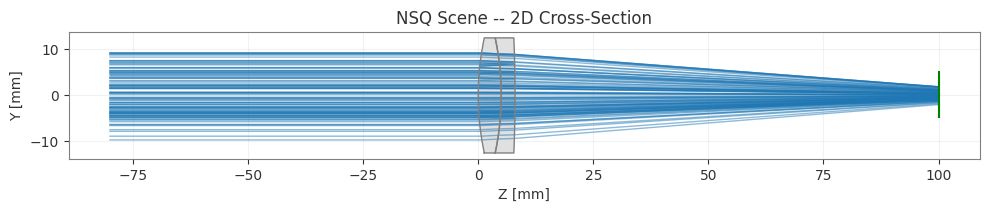

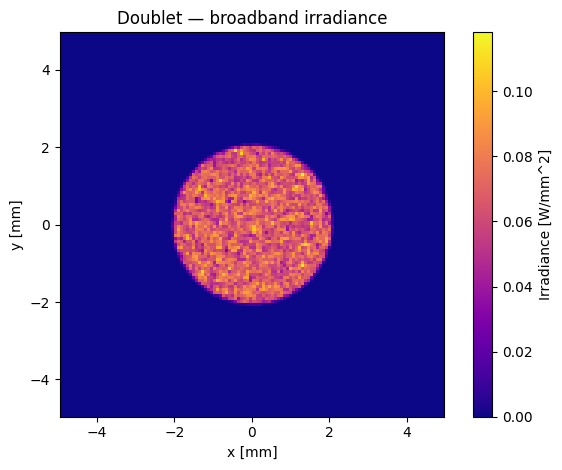

In [4]:
spec_rgb = Spectrum(
    wavelengths=np.array([0.45, 0.55, 0.65]),
    weights=np.array([1.0, 1.0, 1.0]),
)

doublet_config = DoubletConfig(
    r1=60.0, r2=-60.0, r3=-300.0,
    thickness1=5.0, thickness2=3.0,
    material1='N-BK7', material2='N-SF5',
    aperture_radius=12.5,
)

scene = NSQScene()
scene.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_rgb, total_flux=1.0, aperture_radius=10.0),
)
scene.add_doublet('D1', CoordinateSystem(z=0), doublet_config)
scene.add_detector(
    'Det', CoordinateSystem(z=100),
    IrradianceDetectorConfig(width=10, height=10, num_pixels_x=128, num_pixels_y=128),
)

scene.view()

result = scene.trace(num_rays=30_000, seed=42)
irr = result.detectors['Det']

print(f"Doublet surfaces   : {len(scene.surfaces)}")
print(f"Rays on detector   : {irr.num_rays_hit:,}")
print(f"Flux on detector   : {irr.total_flux:.4f} W")

fig = irr.plot(cmap='plasma')
plt.title('Doublet — broadband irradiance')
plt.tight_layout()
plt.show()

## 4. Mirror

`MirrorConfig` has three parameters:
- `radius` — vertex radius of curvature [mm]. Negative = concave when facing +z
- `conic` — conic constant (0 = sphere, -1 = paraboloid, <−1 = hyperboloid)
- `aperture_radius` — semi-diameter [mm]

A **parabolic mirror** (`conic=-1`) focuses a collimated on-axis beam to a perfect
geometrical point (no spherical aberration).

We orient the mirror with `rx=π` so its reflecting face points toward the incoming
collimated beam traveling in `+z`, and place the detector at the focal point.

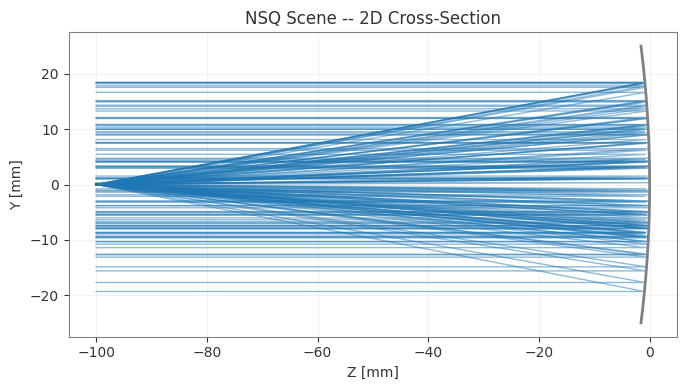

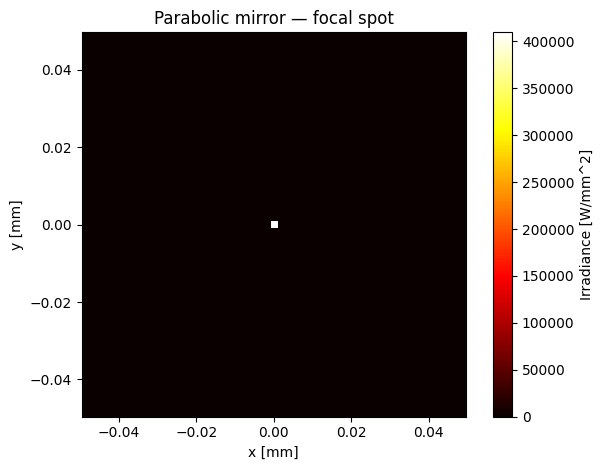

Rays on detector: 30,000 | Flux: 1.0000 W


In [5]:
# Parabolic mirror: f = |R|/2 = 100 mm, R = -200 mm (concave toward -z incoming beam)
# We flip the mirror 180° around x so it faces the incoming beam
mirror_config = MirrorConfig(radius=-200, conic=-1.0, aperture_radius=25.0)

scene_m = NSQScene()
scene_m.add_source(
    'S', CoordinateSystem(z=-100),
    CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=20.0),
)
# Mirror at z=0, tilted 180° so its concave surface faces -z (toward source)
scene_m.add_mirror('M', CoordinateSystem(z=0), mirror_config)

# Focal plane: f = |R|/2 = 100 mm. Mirror is at z=0, beam enters from z<0,
# so reflected focus is at z = -100 mm.
scene_m.add_detector(
    'Det', CoordinateSystem(z=-100),
    IrradianceDetectorConfig(width=0.1, height=0.1, num_pixels_x=128, num_pixels_y=128),
)

scene_m.view()

result_m = scene_m.trace(num_rays=30_000, seed=42)
irr_m = result_m.detectors['Det']

fig = irr_m.plot(cmap='hot')
plt.title('Parabolic mirror — focal spot')
plt.tight_layout()
plt.show()

print(f"Rays on detector: {irr_m.num_rays_hit:,} | Flux: {irr_m.total_flux:.4f} W")

## 5. Per-Surface Overrides with `SurfaceConfig`

`LensConfig.front`, `.back`, `.edge`, and `.rim` accept a `SurfaceConfig` to
override defaults on a per-surface basis:

- `interaction` — force `REFRACTIVE`, `REFLECTIVE`, or `ABSORBING`
- `bsdf` — attach a scatter model (see the Scattering notebook)
- `aperture_radius` — override the semi-diameter for that surface

Below we make the *back face* of the lens partially reflective (mirror-like)
to simulate a partially coated surface:

C:\Users\kdani\Documents\Python_Scripts\optiland\optiland\nonsequential\bsdf\lambertian.py:127: RuntimeWarning: invalid value encountered in divide
  t_vec /= (t_vec * t_vec).sum(axis=1, keepdims=True) ** 0.5


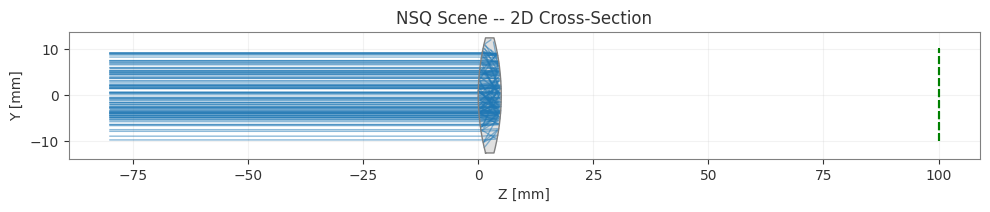

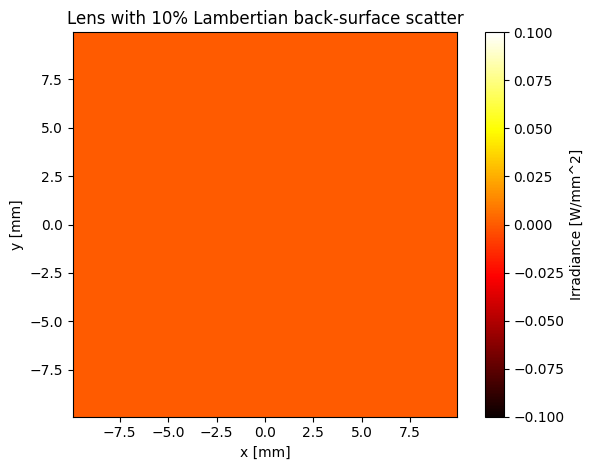

In [6]:
# Lens with a diffuse-scatter back surface (Lambertian BSDF, 80% reflectance)
scatter_config = LensConfig(
    r1=50, r2=-50, thickness=5, material='N-BK7',
    front_aperture_radius=12.5,
    back=SurfaceConfig(
        bsdf=LambertianBSDF(reflectance_value=0.1),  # 10% back-surface scatter
    ),
)

scene_sc = NSQScene()
scene_sc.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0),
)
scene_sc.add_lens('L', CoordinateSystem(z=0), scatter_config)
scene_sc.add_detector(
    'D', CoordinateSystem(z=100),
    IrradianceDetectorConfig(width=20, height=20, num_pixels_x=128, num_pixels_y=128),
)

scene_sc.view()

result_sc = scene_sc.trace(num_rays=30_000, seed=42)
irr_sc = result_sc.detectors['D']

fig = irr_sc.plot(cmap='hot')
plt.title('Lens with 10% Lambertian back-surface scatter')
plt.tight_layout()
plt.show()

## Summary

- `LensConfig(r1, r2, thickness, material, front_aperture_radius)` — singlet refractive element
- `DoubletConfig(r1, r2, r3, thickness1, thickness2, material1, material2, aperture_radius)` — cemented achromat
- `MirrorConfig(radius, conic, aperture_radius)` — conic reflective mirror
- Glass names (`'N-BK7'`, `'N-SF5'`, ...) are looked up in the Optiland material catalog
- `SurfaceConfig` overrides individual surface properties (BSDF, interaction type, aperture)
- `VACUUM` constant for a lossless n=1 medium